In [ ]:
!pip install yfinance tensorflow matplotlib seaborn --quiet

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:

import yfinance as yf

from datetime import datetime

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM
tech_list = ["AAPL", "GOOG", "MSFT", "AMZN"]

end = datetime.now()
start = datetime(end.year - 1, end.month, end.day)

df = yf.download(
    tech_list,
    start=start,
    end=end
)

df.head()

/tmp/ipykernel_1187/626861662.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(
[*********************100%***********************]  4 of 4 completed


Price            Close                                            High  \
Ticker            AAPL        AMZN        GOOG        MSFT        AAPL   
Date                                                                     
2025-03-17  213.071350  195.740005  165.996140  385.746887  214.286057   
2025-03-18  211.767029  192.820007  162.109573  380.606201  214.216345   
2025-03-19  214.305954  195.539993  165.707123  384.873566  217.810668   
2025-03-20  213.170929  194.949997  164.481384  383.901001  216.546218   
2025-03-21  217.322815  196.210007  165.677246  388.287445  217.890334   

Price                                                  Low              \
Ticker            AMZN        GOOG        MSFT        AAPL        AMZN   
Date                                                                     
2025-03-17  199.000000  167.879627  389.726401  209.058839  194.320007   
2025-03-18  194.000000  165.866589  384.426957  210.572239  189.380005   
2025-03-19  195.970001  167.553736  386.719420  212.822414  191.960007   
2025-03-20  199.320007  166.454559  388.813406  211.299082  192.300003   
2025-03-21  196.990005  165.896489  388.763779  210.363143  192.520004   

Price                                     Open                          \
Ticker            GOOG        MSFT        AAPL        AMZN        GOOG   
Date                                                                     
2025-03-17  165.238748  382.640662  212.384342  198.770004  166.748528   
2025-03-18  158.252911  378.204604  213.230651  192.520004  165.388247   
2025-03-19  162.488255  381.082581  213.290376  193.380005  163.350265   
2025-03-20  162.577961  380.368050  213.061406  193.070007  163.260598   
2025-03-21  162.468338  379.891697  210.641927  192.899994  162.817139   

Price                     Volume                                
Ticker            MSFT      AAPL      AMZN      GOOG      MSFT  
Date                                                            
2025-03-17  383.762082  48073400  47341800  17839100  22474300  
2025-03-18  384.129248  42432400  40414900  24616800  19486900  
2025-03-19  382.600955  54385400  39442900  24955700  19185500  
2025-03-20  382.809352  48862900  38921100  19981500  18470500  
2025-03-21  380.308520  94127800  60056900  29882100  39675900

In [ ]:
#Summary Start
df[df.columns.levels[0]].describe()

Price        Close                                            High  \
Ticker        AAPL        AMZN        GOOG        MSFT        AAPL   
count   250.000000  250.000000  250.000000  250.000000  250.000000   
mean    237.233567  218.008960  237.582059  465.499642  239.760860   
std      29.299344   17.563698   63.894753   48.983770   29.202377   
min     171.671783  167.320007  146.075012  351.866241  189.514018   
25%     209.417725  207.912502  174.107838  429.487076  211.360834   
50%     237.856644  221.625000  240.753204  480.139099  239.668187   
75%     264.307503  230.697506  305.958649  506.224953  267.179901   
max     285.922455  254.000000  344.657196  539.825195  288.350192   

Price                                              Low              \
Ticker        AMZN        GOOG        MSFT        AAPL        AMZN   
count   250.000000  250.000000  250.000000  250.000000  250.000000   
mean    220.505520  240.353469  469.534365  234.659417  215.350160   
std      17.393450   64.593828   48.716403   29.446966   18.113763   
min     169.600006  150.539567  361.710895  168.475722  161.380005   
25%     210.337502  176.972400  434.501132  207.183792  204.379997   
50%     223.580002  242.792937  483.351774  236.045085  219.209999   
75%     232.472496  308.664432  509.404240  261.397977  228.527504   
max     258.600006  349.903504  552.242002  283.035157  252.899994   

Price                                 Open                          \
Ticker        GOOG        MSFT        AAPL        AMZN        GOOG   
count   250.000000  250.000000  250.000000  250.000000  250.000000   
mean    234.410714  461.278695  237.072423  218.018240  237.321710   
std      63.066644   49.665381   29.460579   18.087640   63.949386   
min     142.168513  342.170496  171.203815  162.000000  142.895994   
25%     172.346134  422.623588  209.335475  207.340000  174.277438   
50%     237.981969  475.015798  238.255877  221.895004  240.588427   
75%     301.537589  502.388562  263.572502  230.732506  304.520793   
max     338.351644  538.530591  285.932471  255.360001  348.269676   

Price                     Volume                                            
Ticker        MSFT          AAPL          AMZN          GOOG          MSFT  
count   250.000000  2.500000e+02  2.500000e+02  2.500000e+02  2.500000e+02  
mean    465.587115  5.327817e+07  4.698636e+07  2.416646e+07  2.483712e+07  
std      49.586411  2.337728e+07  2.186011e+07  1.023623e+07  1.249256e+07  
min     348.214224  1.791060e+07  1.142050e+07  6.138200e+06  5.855900e+06  
25%     429.002353  3.980698e+07  3.458250e+07  1.812590e+07  1.678188e+07  
50%     479.794485  4.700195e+07  4.137405e+07  2.176490e+07  2.134610e+07  
75%     506.307120  5.582172e+07  5.149288e+07  2.612160e+07  2.853578e+07  
max     552.023241  1.843959e+08  1.792109e+08  7.872980e+07  1.288553e+08

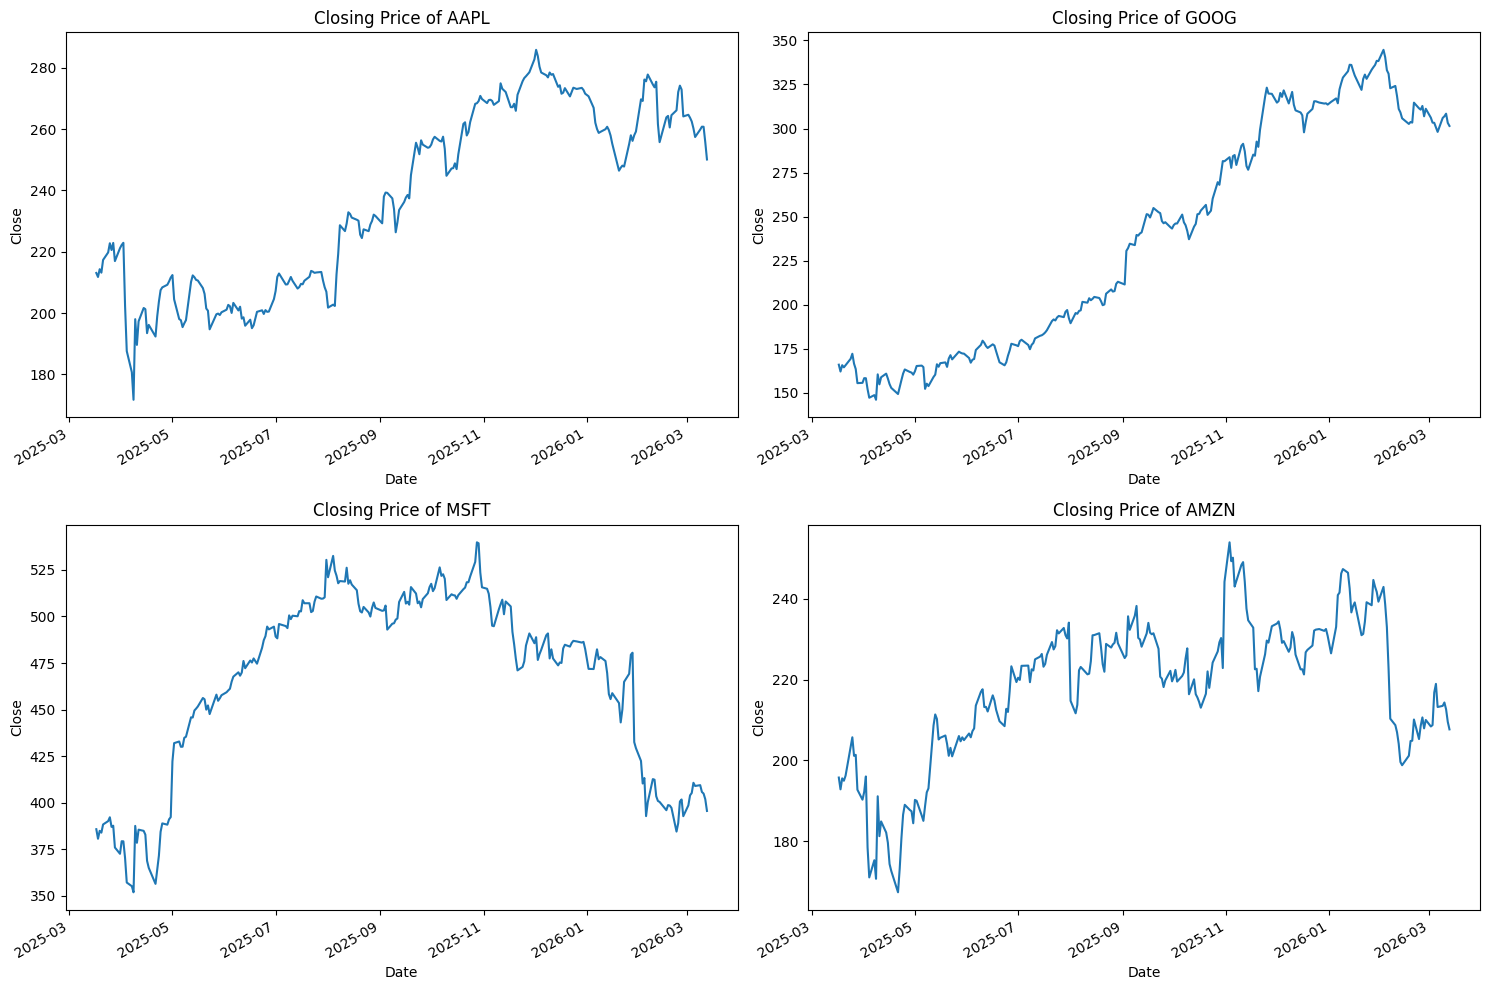

In [ ]:
plt.figure(figsize=(15,10))

for i, company in enumerate(tech_list,1):
  plt.subplot(2,2,i)
  df['Close'][company].plot()
  plt.title(f"Closing Price of {company}")
  plt.ylabel("Close")
plt.tight_layout()
plt.show()

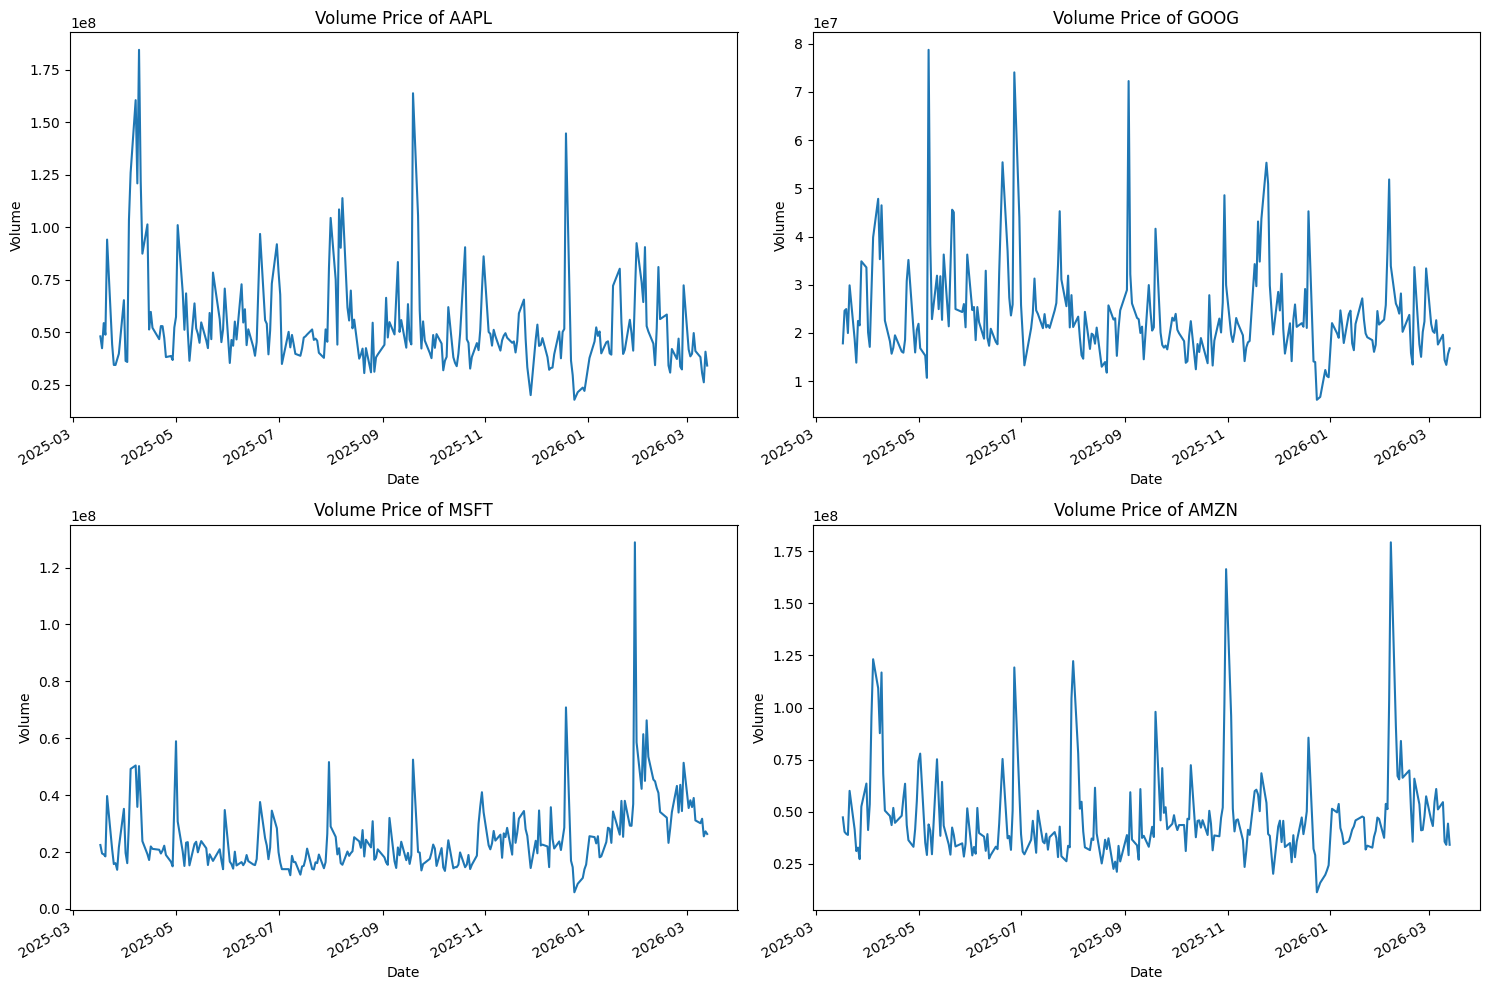

In [ ]:
plt.figure(figsize=(15,10))

for i, company in enumerate(tech_list,1):
  plt.subplot(2,2,i)
  df['Volume'][company].plot()
  plt.title(f"Volume Price of {company}")
  plt.ylabel("Volume")
plt.tight_layout()
plt.show()

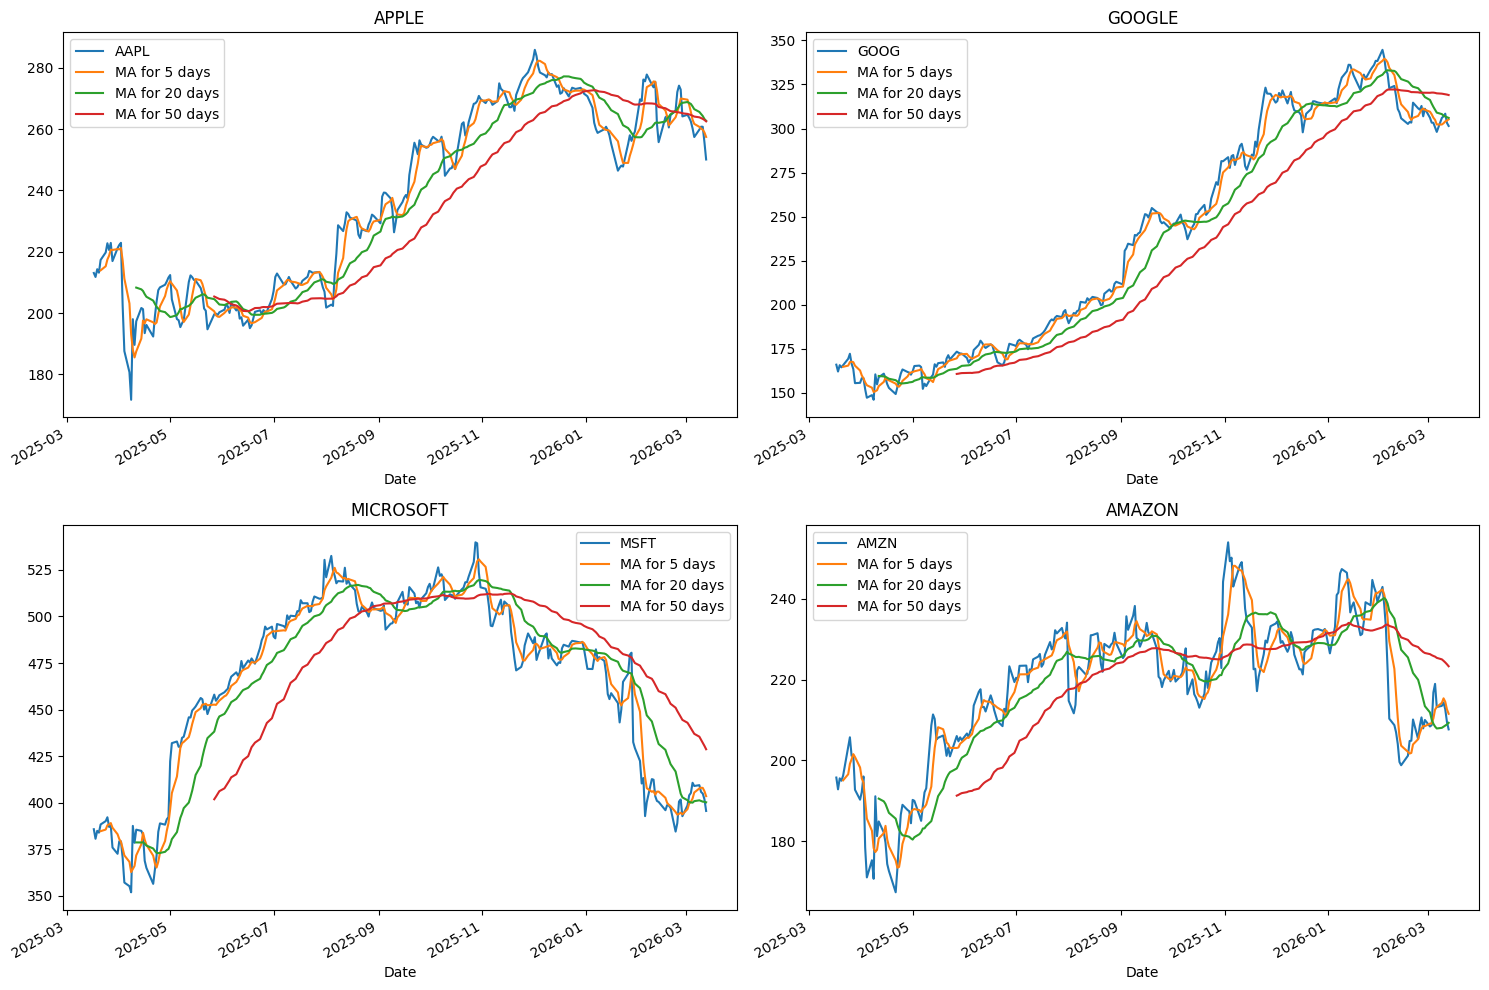

In [ ]:
ma_day = [5, 10, 20, 50]

for ma in ma_day:
    for company in tech_list:
        column_name = f"MA for {ma} days"
        df[('Close', company), column_name] = df['Close'][company].rolling(ma).mean()

fig, axes = plt.subplots(nrows=2, ncols=2)
fig.set_figheight(10)
fig.set_figwidth(15)

# Assuming AAPL, GOOG, MSFT, AMZN are DataFrames for each company; if not, adjust accordingly
# If df is multi-index, use df['Close']['AAPL'] etc., but plotting might need individual DataFrames

# For plotting, create individual DataFrames if needed
AAPL = df['Close']['AAPL'].to_frame()
GOOG = df['Close']['GOOG'].to_frame()
MSFT = df['Close']['MSFT'].to_frame()
AMZN = df['Close']['AMZN'].to_frame()

# Add MA columns to each
for ma in ma_day:
    AAPL[f'MA for {ma} days'] = AAPL['AAPL'].rolling(ma).mean()
    GOOG[f'MA for {ma} days'] = GOOG['GOOG'].rolling(ma).mean()
    MSFT[f'MA for {ma} days'] = MSFT['MSFT'].rolling(ma).mean()
    AMZN[f'MA for {ma} days'] = AMZN['AMZN'].rolling(ma).mean()

AAPL[['AAPL', 'MA for 5 days', 'MA for 20 days', 'MA for 50 days']].plot(ax=axes[0,0])
axes[0,0].set_title('APPLE')

GOOG[['GOOG', 'MA for 5 days', 'MA for 20 days', 'MA for 50 days']].plot(ax=axes[0,1])
axes[0,1].set_title('GOOGLE')

MSFT[['MSFT', 'MA for 5 days', 'MA for 20 days', 'MA for 50 days']].plot(ax=axes[1,0])
axes[1,0].set_title('MICROSOFT')

AMZN[['AMZN', 'MA for 5 days', 'MA for 20 days', 'MA for 50 days']].plot(ax=axes[1,1])
axes[1,1].set_title('AMAZON')

fig.tight_layout()

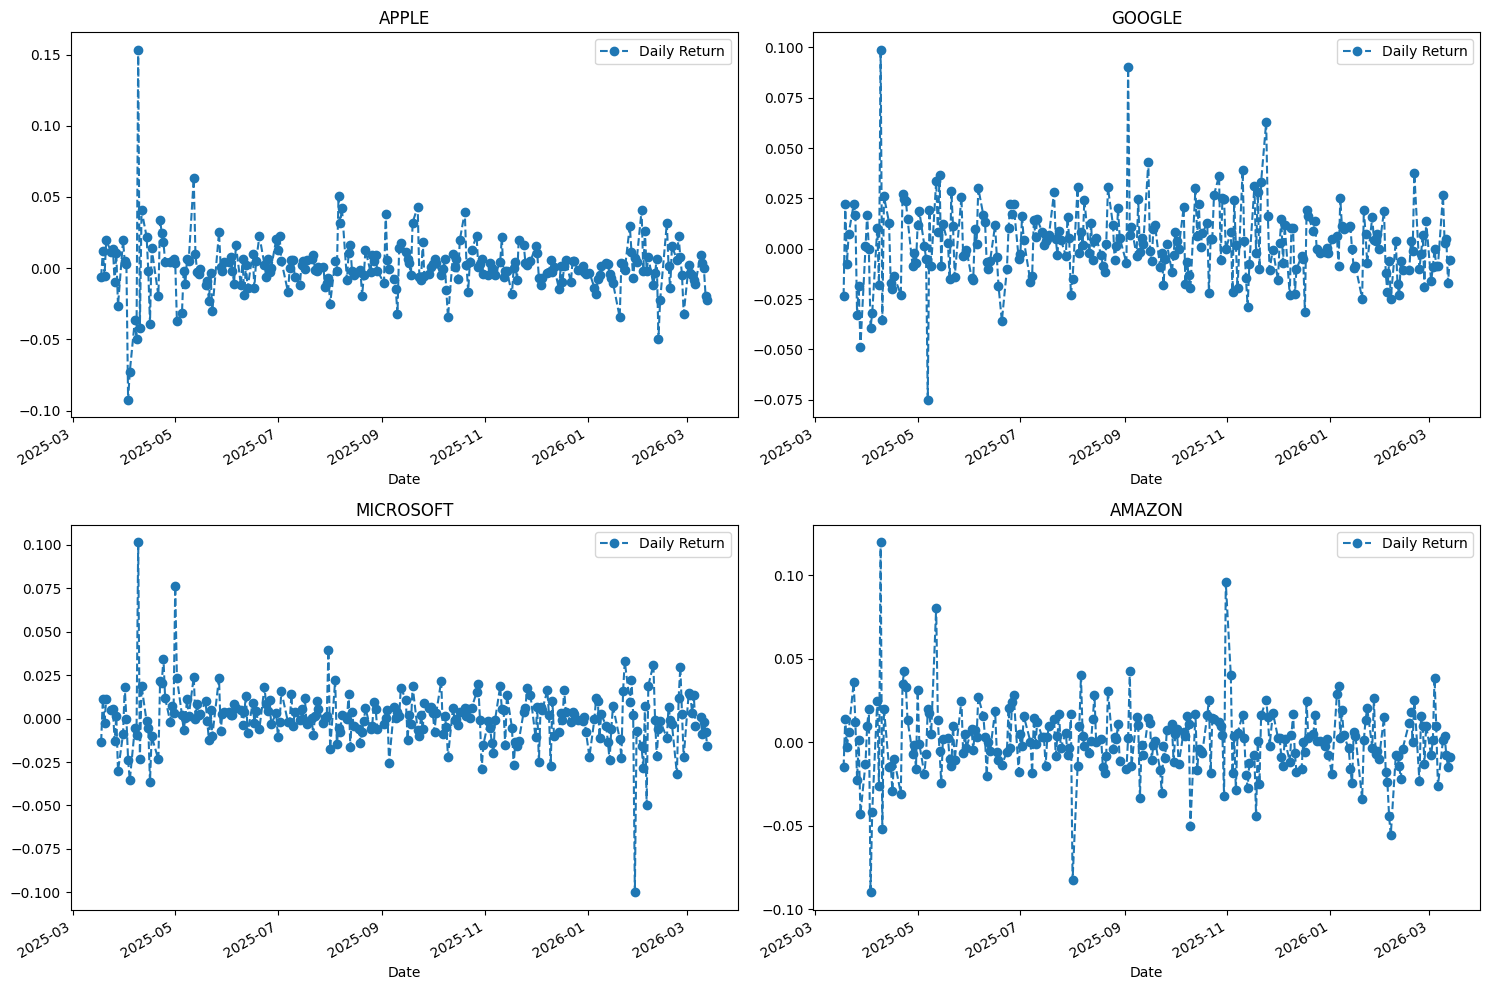

In [ ]:
# We'll use pct_change to find the percent change for each day
for company in tech_list:
    df[('Close', company), 'Daily Return'] = df['Close'][company].pct_change()

# Then we'll plot the daily return percentage
fig, axes = plt.subplots(nrows=2, ncols=2)
fig.set_figheight(10)
fig.set_figwidth(15)

# Assuming AAPL, GOOG, MSFT, AMZN are DataFrames for each company; if not, adjust accordingly
# If df is multi-index, use df['Close']['AAPL'] etc., but plotting might need individual DataFrames

# For plotting, create individual DataFrames if needed
AAPL = df['Close']['AAPL'].to_frame()
GOOG = df['Close']['GOOG'].to_frame()
MSFT = df['Close']['MSFT'].to_frame()
AMZN = df['Close']['AMZN'].to_frame()

# Add Daily Return columns to each
AAPL['Daily Return'] = df[('Close', 'AAPL'), 'Daily Return']
GOOG['Daily Return'] = df[('Close', 'GOOG'), 'Daily Return']
MSFT['Daily Return'] = df[('Close', 'MSFT'), 'Daily Return']
AMZN['Daily Return'] = df[('Close', 'AMZN'), 'Daily Return']

AAPL['Daily Return'].plot(ax=axes[0,0], legend=True, linestyle='--', marker='o')
axes[0,0].set_title('APPLE')

GOOG['Daily Return'].plot(ax=axes[0,1], legend=True, linestyle='--', marker='o')
axes[0,1].set_title('GOOGLE')

MSFT['Daily Return'].plot(ax=axes[1,0], legend=True, linestyle='--', marker='o')
axes[1,0].set_title('MICROSOFT')

AMZN['Daily Return'].plot(ax=axes[1,1], legend=True, linestyle='--', marker='o')
axes[1,1].set_title('AMAZON')

fig.tight_layout()

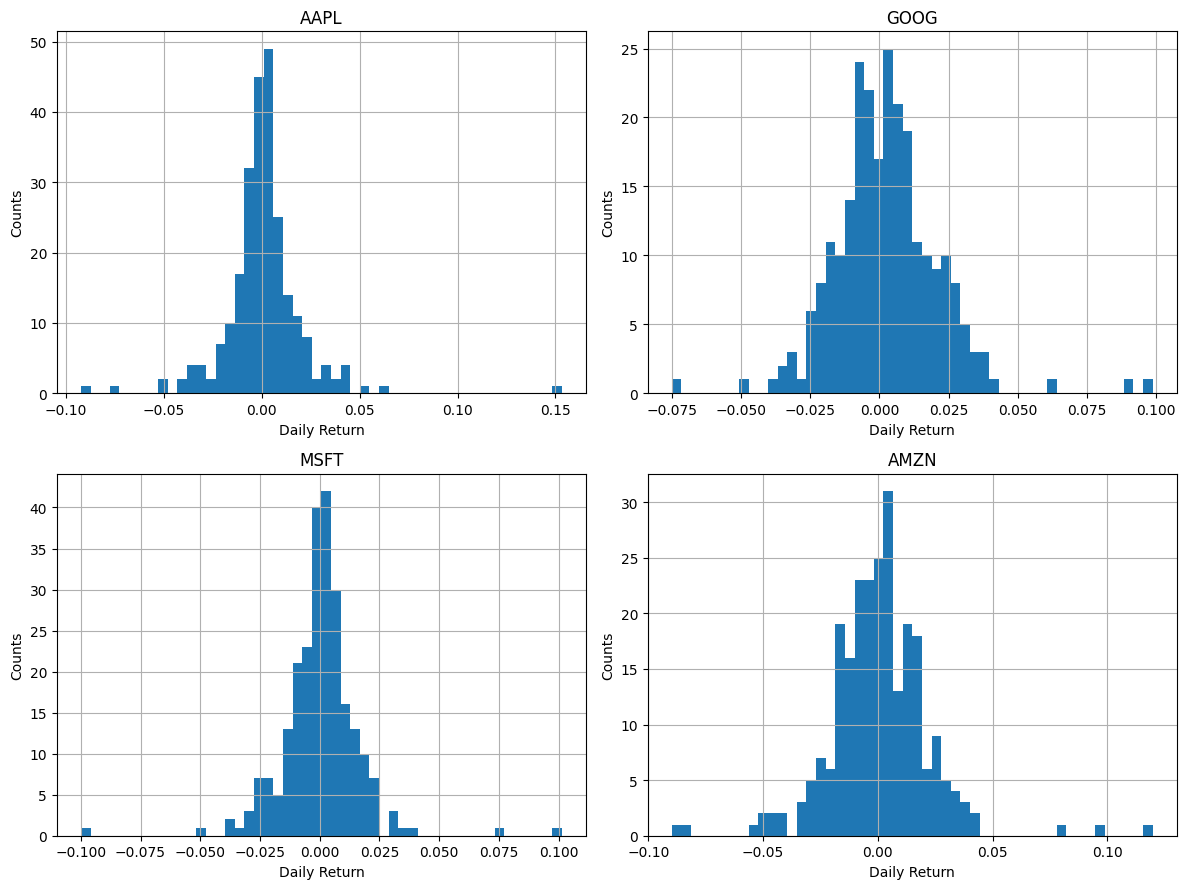

In [ ]:
plt.figure(figsize=(12, 9))

for i, company in enumerate(tech_list, 1):
  plt.subplot(2, 2, i)
  df[('Close', company), 'Daily Return'].hist(bins=50)
  plt.xlabel('Daily Return')
  plt.ylabel('Counts')
  plt.title(f'{company}')

plt.tight_layout()

In [ ]:
#Grab all the closing prices for the tech stock list into one DataFrame
closing_df = yf.download(tech_list, start=start, end=end)['Close']

#Make a new tech returns DataFrame
tech_rets = closing_df.pct_change()
tech_rets.head()

/tmp/ipykernel_1187/1362448408.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  closing_df = yf.download(tech_list, start=start, end=end)['Close']
[*********************100%***********************]  4 of 4 completed


Ticker,AAPL,AMZN,GOOG,MSFT
Date,,,,
2025-03-17,NaN,NaN,NaN,NaN
2025-03-18,-0.006122,-0.014918,-0.023414,-0.013327
2025-03-19,0.011989,0.014106,0.022192,0.011212
2025-03-20,-0.005296,-0.003017,-0.007397,-0.002527
2025-03-21,0.019477,0.006463,0.007271,0.011426


AttributeError: QuadMesh.set() got an unexpected keyword argument 'ammot'

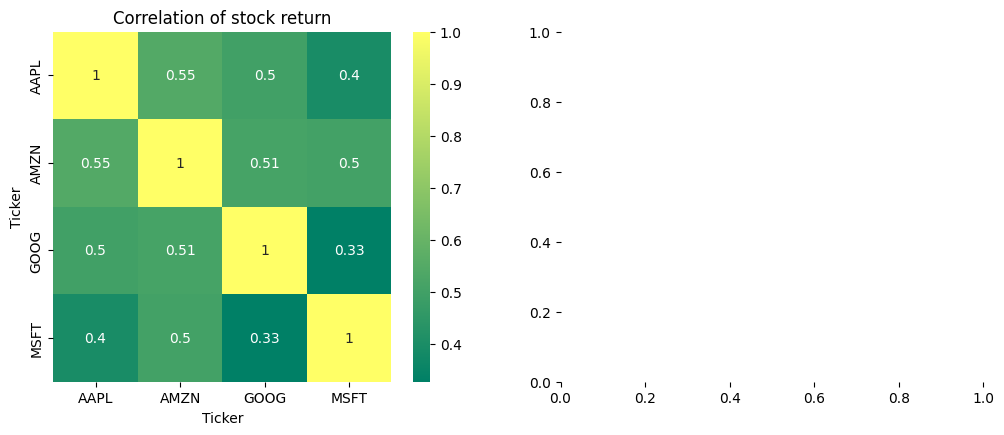

In [ ]:
plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
sns.heatmap(tech_rets.corr(), annot=True, cmap='summer')
plt.title('Correlation of stock return')

plt.subplot(2, 2, 2)
sns.heatmap(closing_df.corr(), ammot=True, cmap='summer')
plt.title('Correlation of stock closing price')

Text(0.5, 1.0, 'Correlation of Tech Returns')

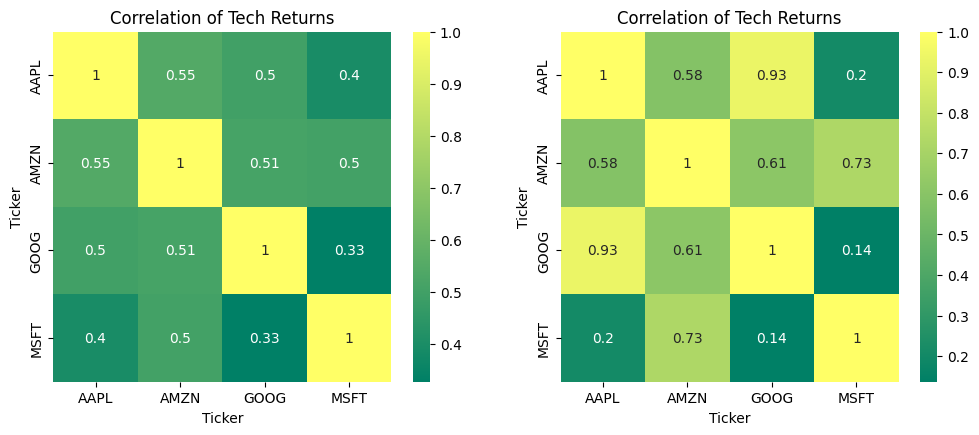

In [ ]:
plt.figure(figsize=(12,10))

plt.subplot(2, 2, 1)
sns.heatmap(tech_rets.corr(), annot=True, cmap='summer')
plt.title('Correlation of Tech Returns')

plt.subplot(2, 2, 2)
sns.heatmap(closing_df.corr(), annot=True, cmap='summer')
plt.title('Correlation of Tech Returns')


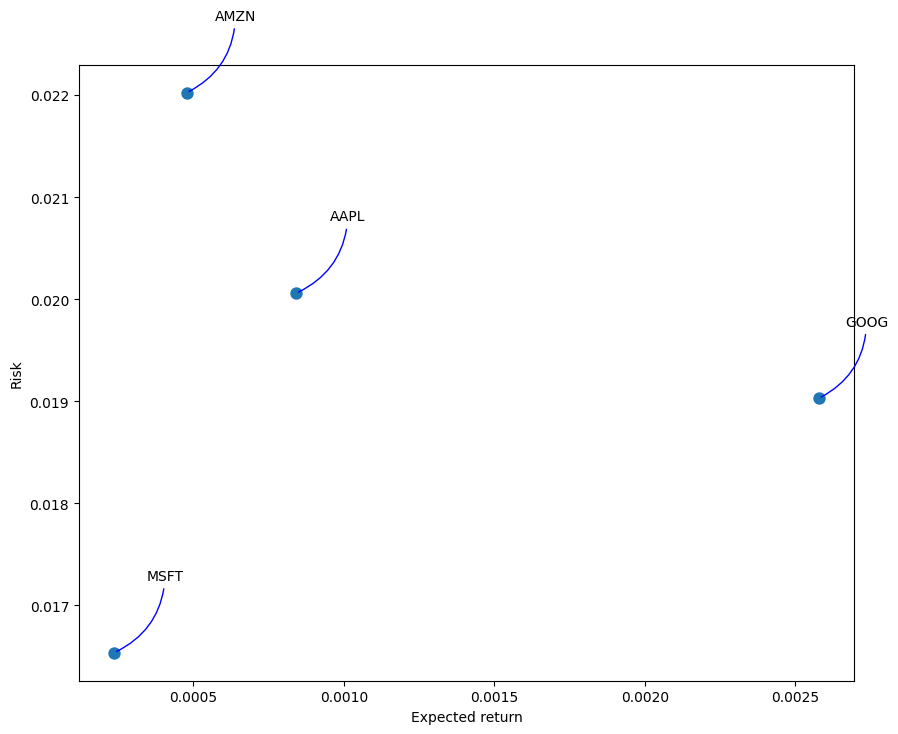

In [ ]:
rets = tech_rets.dropna()

area = np.pi * 20

plt.figure(figsize=(10, 8))
plt.scatter(rets.mean(), rets.std(), s=area)
plt.xlabel('Expected return')
plt.ylabel('Risk')

for label, x, y in zip(rets.columns, rets.mean(), rets.std()):
    plt.annotate(label, xy=(x, y), xytext=(50, 50), textcoords='offset points',
                 ha='right', va='bottom',
                 arrowprops=dict(arrowstyle='-', color='blue',
                                 connectionstyle='arc3,rad=-0.3'))

In [ ]:
#List the stock quote
df = yf.download('AAPL', start='2012-01-01', end=datetime.now())
#Show the data
df

/tmp/ipykernel_1187/1477385287.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('AAPL', start='2012-01-01', end=datetime.now())
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2012-01-03,12.321689,12.359742,12.254872,12.266857,302220800
2012-01-04,12.387904,12.425059,12.263258,12.284831,260022000
2012-01-05,12.525436,12.541017,12.364834,12.433151,271269600
2012-01-06,12.656374,12.666861,12.561092,12.577571,318292800
2012-01-09,12.636297,12.816675,12.624911,12.749258,394024400
...,...,...,...,...,...
2026-03-09,259.880005,261.149994,253.679993,255.690002,38218500
2026-03-10,260.829987,262.480011,256.950012,257.649994,30590800


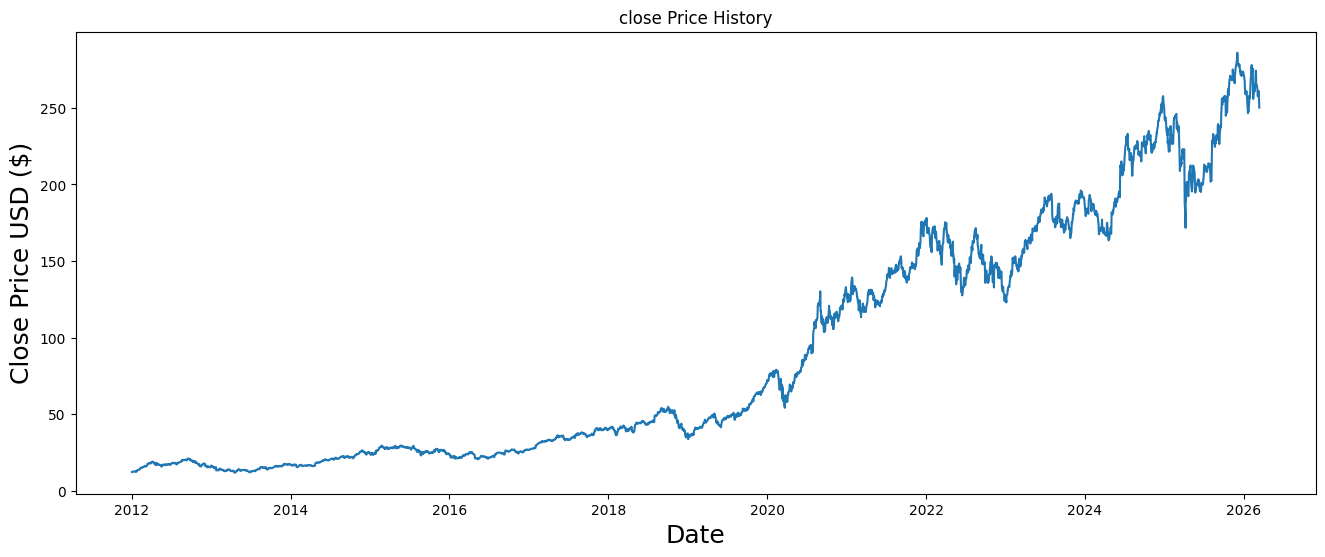

In [ ]:
plt.figure(figsize=(16,6))
plt.title('close Price History')
plt.plot(df['Close'])
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price USD ($)', fontsize=18)
plt.show()

In [ ]:
#Create a new dataFrame with only the 'Close column
data = df[['Close']]
#Convert the dataFrame to a numpy array
dataset = data.values
#Get the number of rows to train the model on
training_data_len = int(np.ceil( len(dataset) * .95 ))

training_data_len

3391

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(dataset)

scaled_data

array([[0.00163298],
       [0.0018746 ],
       [0.00237646],
       ...,
       [0.90836484],
       [0.88993742],
       [0.86935711]])

In [ ]:
# Create the training data set
# Create the scaled training data set
train_data = scaled_data[0:int(training_data_len), :]
# Split the data into x_train and y_train data sets
x_train = []
y_train = []

for i in range(60, len(train_data)):
    x_train.append(train_data[i-60:i, 0])
    y_train.append(train_data[i, 0])
    if i<= 61:
        print(x_train)
        print(y_train)
        print()

# Convert the x_train and y_train to numpy arrays
x_train, y_train = np.array(x_train), np.array(y_train)

# Reshape the data
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))
# x_train.shape


[array([0.00163298, 0.0018746 , 0.00237646, 0.00285425, 0.00278099,
       0.00294608, 0.00287065, 0.00274382, 0.00257106, 0.00310571,
       0.00358788, 0.00343919, 0.00262464, 0.00340201, 0.00263667,
       0.00550671, 0.00528476, 0.00557451, 0.00620098, 0.00658039,
       0.00654867, 0.00643167, 0.00693025, 0.0073993 , 0.00793066,
       0.00878894, 0.01059186, 0.0106192 , 0.0116229 , 0.01237293,
       0.0110839 , 0.01158025, 0.01157041, 0.01296223, 0.01276436,
       0.01313061, 0.01378882, 0.01415508, 0.01521018, 0.0159788 ,
       0.01620075, 0.01627838, 0.01496419, 0.01464709, 0.01469412,
       0.0159296 , 0.01627729, 0.01702406, 0.01878432, 0.02113285,
       0.02069331, 0.02069441, 0.02239239, 0.02292374, 0.02254539,
       0.02219995, 0.02184023, 0.02303529, 0.02385527, 0.02419858])]
[np.float64(0.023350123349611097)]

[array([0.00163298, 0.0018746 , 0.00237646, 0.00285425, 0.00278099,
       0.00294608, 0.00287065, 0.00274382, 0.00257106, 0.00310571,
       0.00358788, 0.0

In [ ]:
from keras.models import Sequential
from keras.layers import Dense, LSTM

# Build the LSTM model
model = Sequential()
model.add(LSTM(128, return_sequences=True, input_shape= (x_train.shape[1], 1)))
model.add(LSTM(64, return_sequences=False))
model.add(Dense(25))
model.add(Dense(1))

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
model.fit(x_train, y_train, batch_size=1, epochs=1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


3331/3331 ━━━━━━━━━━━━━━━━━━━━ 147s 43ms/step - loss: 0.0011


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 140ms/step
18.733860533577154


/tmp/ipykernel_1187/619668229.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['Predictions'] = predictions


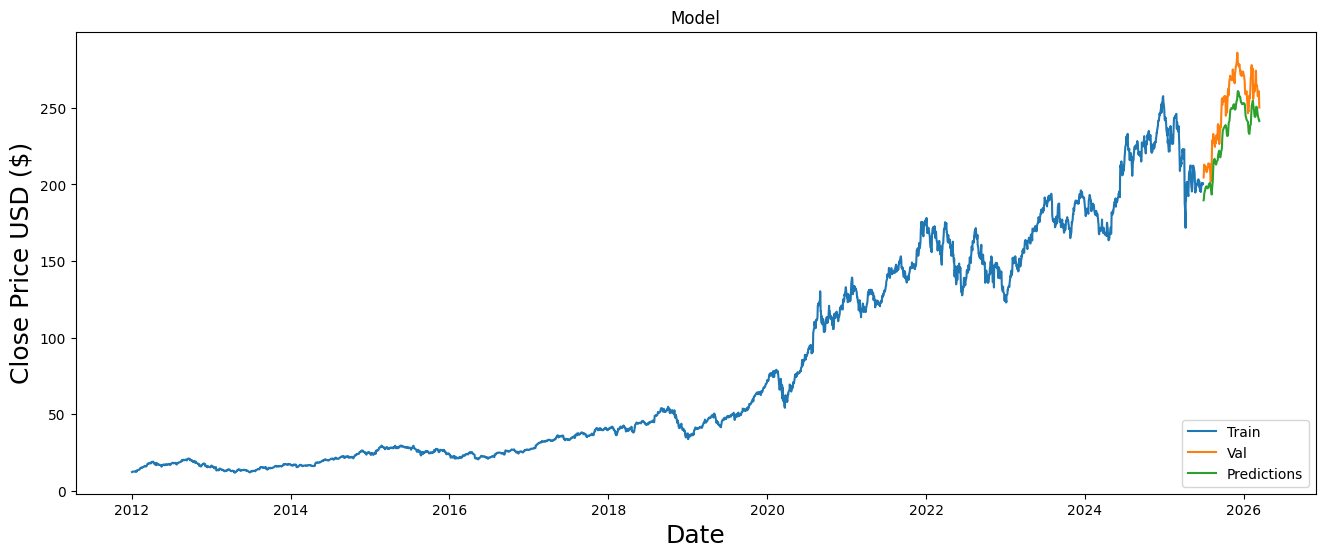

In [ ]:
# Create the testing data set
# Create a new array containing scaled values from index 1543 to 2002
test_data = scaled_data[training_data_len - 60: , :]
# Create the data sets x_test and y_test
x_test = []
y_test = dataset[training_data_len:, :]
for i in range(60, len(test_data)):
    x_test.append(test_data[i-60:i, 0])

# Convert the data to a numpy array
x_test = np.array(x_test)

# Reshape the data
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1 ))

# Get the models predicted price values
predictions = model.predict(x_test)
predictions = scaler.inverse_transform(predictions)

# Get the root mean squared error (RMSE)
rmse = np.sqrt(np.mean(((predictions - y_test) ** 2)))
print(rmse)


# Plot the data
train = data[:training_data_len]
valid = data[training_data_len:]
valid['Predictions'] = predictions
# Visualize the data
plt.figure(figsize=(16,6))
plt.title('Model')
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price USD ($)', fontsize=18)
plt.plot(train['Close'])
plt.plot(valid[['Close', 'Predictions']])
plt.legend(['Train', 'Val', 'Predictions'], loc='lower right')
plt.show()